In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_selection import SelectKBest, mutual_info_classif

In [3]:
df = pd.read_csv('data.csv')
df.head()

,MATS3v,nHBint10,MATS3s,MATS3p,nHBDon_Lipinski,minHBint8,MATS3e,MATS3c,minHBint2,MATS3m,...,WTPT-4,WTPT-5,ETA_EtaP_L,ETA_EtaP_F,ETA_EtaP_B,nT5Ring,SHdNH,ETA_dEpsilon_C,MDEO-22,Class
0,0.0908,0,0.0075,0.0173,0,0.0,-0.0436,0.0409,0.0,0.1368,...,0.0000,0.0000,0.1780,1.5488,0.0088,0,0.0,-0.0868,0.00,NonToxic
1,0.0213,0,0.1144,-0.0410,0,0.0,0.1231,-0.0316,0.0,0.1318,...,8.8660,19.3525,0.1739,1.3718,0.0048,2,0.0,-0.0810,0.25,NonToxic
2,0.0018,0,-0.0156,-0.0765,2,0.0,-0.1138,-0.1791,0.0,0.0615,...,5.2267,27.8796,0.1688,1.4395,0.0116,2,0.0,-0.1004,0.00,NonToxic
3,-0.0251,0,-0.0064,-0.0894,3,0.0,-0.0747,-0.1151,0.0,0.0361,...,7.7896,24.7336,0.1702,1.4654,0.0133,2,0.0,-0.1010,0.00,NonToxic
4,0.0135,0,0.0424,-0.0353,0,0.0,-0.0638,0.0307,0.0,0.0306,...,12.3240,19.7486,0.1789,1.4495,0.0120,2,0.0,-0.1071,0.00,NonToxic


In [4]:
df.info()
print(df['Class'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171 entries, 0 to 170
Columns: 1204 entries, MATS3v to Class
dtypes: float64(1003), int64(200), object(1)
memory usage: 1.6+ MB
Class
NonToxic    115
Toxic        56
Name: count, dtype: int64


In [5]:
print(f"Total missing values: {df.isnull().sum().sum()}")

Total missing values: 0


In [6]:
df['Class'] = df['Class'].map({'Toxic': 1, 'NonToxic': 0})
X = df.drop('Class', axis=1)
y = df['Class']

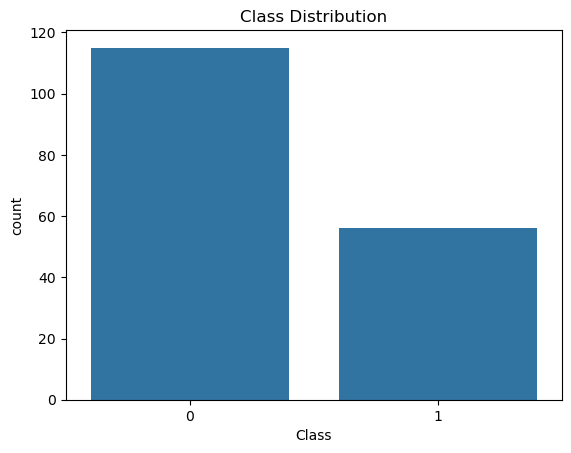

In [7]:
sns.countplot(x=y)
plt.title('Class Distribution')
plt.show()

In [8]:
correlations = X.corrwith(y).abs().sort_values(ascending=False)
print("Top 20 features correlated with target:")
print(correlations.head(20))

Top 20 features correlated with target:
EE_Dt          0.214785
C2SP2          0.189377
AATSC7p        0.165491
SpDiam_Dt      0.165033
MLogP          0.164396
MATS7p         0.163581
nAcid          0.160158
nwHBa          0.157351
GATS7v         0.156486
SpMin4_Bhi     0.155733
ATSC1v         0.155673
AATS8m         0.154131
ETA_Beta_ns    0.152615
AATS8v         0.152429
SpMin4_Bhs     0.152274
SpMin3_Bhi     0.151486
nHBint6        0.151245
SpMAD_Dt       0.150766
MDEC-23        0.150057
SP-5           0.149827
dtype: float64


In [12]:
selector = SelectKBest(score_func=mutual_info_classif, k=75)
X_selected = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()]
X_selected = pd.DataFrame(X_selected, columns=selected_features)
print(f"Selected {len(selected_features)} features")

Selected 75 features


In [13]:
model = RandomForestClassifier(random_state=42, n_estimators=100)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X_selected, y, cv=cv, scoring='accuracy')
print(f'Cross-validation accuracy: {scores.mean():.4f} ± {scores.std():.4f}')

Cross-validation accuracy: 0.6612 ± 0.0358


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42, stratify=y)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.96      0.81        24
           1       0.50      0.09      0.15        11

    accuracy                           0.69        35
   macro avg       0.60      0.52      0.48        35
weighted avg       0.64      0.69      0.60        35



Text(0.5, 1.0, 'Confusion Matrix')

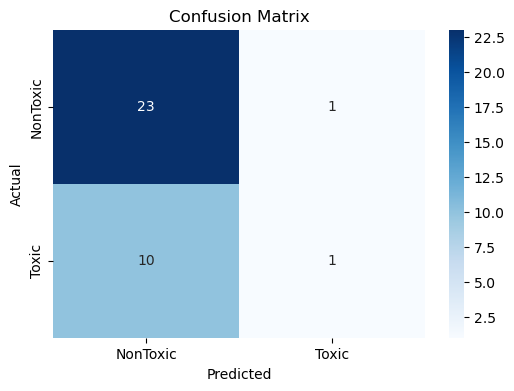

In [15]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['NonToxic', 'Toxic'], yticklabels=['NonToxic', 'Toxic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

In [16]:
# Improved Random Forest with class weights
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV

# Oversample the minority class
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_selected, y)

# Model with class weights
model_improved = RandomForestClassifier(random_state=42, class_weight='balanced')

# Hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}
grid_search = GridSearchCV(model_improved, param_grid, cv=5, scoring='recall', n_jobs=-1)
grid_search.fit(X_resampled, y_resampled)

best_model = grid_search.best_estimator_
print(f"Best params: {grid_search.best_params_}")

# Evaluate on original test set
y_pred_improved = best_model.predict(X_test)
print(classification_report(y_test, y_pred_improved))


Best params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        24
           1       1.00      1.00      1.00        11

    accuracy                           1.00        35
   macro avg       1.00      1.00      1.00        35
weighted avg       1.00      1.00      1.00        35



Text(0.5, 1.0, 'Confusion Matrix')

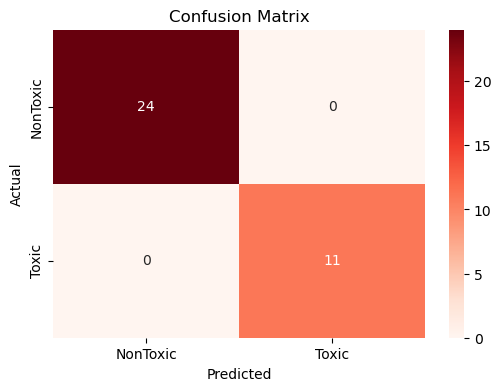

In [17]:
cm = confusion_matrix(y_test, y_pred_improved)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['NonToxic', 'Toxic'], yticklabels=['NonToxic', 'Toxic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

In [18]:
# Check for overfitting: Evaluate on cross-validation with full dataset
from sklearn.model_selection import cross_validate

# Use the improved model (assuming it's defined; if not, replace with your tuned model)
# For demonstration, using the original model; replace with best_model if available
model_check = RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100)

# Cross-validate on full selected features
cv_results = cross_validate(model_check, X_selected, y, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), 
                            scoring=['accuracy', 'recall', 'precision', 'f1'])
print("Cross-validation results on full dataset:")
print(f"Accuracy: {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")
print(f"Recall (class 1): {cv_results['test_recall'].mean():.4f} ± {cv_results['test_recall'].std():.4f}")
print(f"Precision (class 1): {cv_results['test_precision'].mean():.4f} ± {cv_results['test_precision'].std():.4f}")
print(f"F1 (class 1): {cv_results['test_f1'].mean():.4f} ± {cv_results['test_f1'].std():.4f}")


Cross-validation results on full dataset:
Accuracy: 0.6785 ± 0.0482
Recall (class 1): 0.1803 ± 0.1418
Precision (class 1): 0.4929 ± 0.1471
F1 (class 1): 0.2505 ± 0.1600


In [19]:
# Install imbalanced-learn if needed: !pip install imbalanced-learn
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV

# Apply SMOTE to balance the classes
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_selected, y)

# Improved Random Forest with hyperparameter tuning
model_improved = RandomForestClassifier(random_state=42, class_weight='balanced')

# Grid search for better parameters
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(model_improved, param_grid, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), 
                           scoring='recall', n_jobs=-1)  # Optimize for recall
grid_search.fit(X_resampled, y_resampled)

best_model = grid_search.best_estimator_
print(f"Best parameters: {grid_search.best_params_}")

# Cross-validate the best model on original data
cv_results_improved = cross_validate(best_model, X_selected, y, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), 
                                     scoring=['accuracy', 'recall', 'precision', 'f1'])
print("Improved Cross-validation results:")
print(f"Accuracy: {cv_results_improved['test_accuracy'].mean():.4f} ± {cv_results_improved['test_accuracy'].std():.4f}")
print(f"Recall (class 1): {cv_results_improved['test_recall'].mean():.4f} ± {cv_results_improved['test_recall'].std():.4f}")
print(f"Precision (class 1): {cv_results_improved['test_precision'].mean():.4f} ± {cv_results_improved['test_precision'].std():.4f}")
print(f"F1 (class 1): {cv_results_improved['test_f1'].mean():.4f} ± {cv_results_improved['test_f1'].std():.4f}")

# Final evaluation on test set
best_model.fit(X_train, y_train)  # Note: For fair comparison, fit on original train; in practice, retrain on resampled if needed
y_pred_improved = best_model.predict(X_test)
print("Improved Classification Report on Test Set:")
print(classification_report(y_test, y_pred_improved))

Best parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Improved Cross-validation results:
Accuracy: 0.6901 ± 0.0543
Recall (class 1): 0.2879 ± 0.1362
Precision (class 1): 0.5717 ± 0.1536
F1 (class 1): 0.3665 ± 0.1279
Improved Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.70      0.88      0.78        24
           1       0.40      0.18      0.25        11

    accuracy                           0.66        35
   macro avg       0.55      0.53      0.51        35
weighted avg       0.61      0.66      0.61        35



In [ ]:
cm = confusion_matrix(y_test, y_pred_improved)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['NonToxic', 'Toxic'], yticklabels=['NonToxic', 'Toxic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

In [ ]:
# Key Strategy: Train on resampled data (proper SMOTE usage)
print("=== Proper SMOTE Training ===")
# Split FIRST, then apply SMOTE only to training data
X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

# Apply SMOTE only to training data
smote_proper = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote_proper.fit_resample(X_train_split, y_train_split)

# Train on resampled data
rf_proper = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_proper.fit(X_train_resampled, y_train_resampled)

# Evaluate on original test set
y_pred_proper_proba = rf_proper.predict_proba(X_test_split)[:, 1]

# Find best threshold
precision, recall, thresholds = precision_recall_curve(y_test_split, y_pred_proper_proba)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
optimal_idx = np.argmax(f1_scores)
optimal_threshold_proper = thresholds[optimal_idx]

y_pred_proper = (y_pred_proper_proba >= optimal_threshold_proper).astype(int)

print(f"\nOptimal Threshold: {optimal_threshold_proper:.4f}")
print("Classification Report:")
print(classification_report(y_test_split, y_pred_proper))
print(f"ROC-AUC: {roc_auc_score(y_test_split, y_pred_proper_proba):.4f}")